# RQ4 — Housing Equity Challenge Typology in Southwark

**Research Question:** What types of housing equity challenges can be identified across Southwark, and what policy interventions do they imply?

**Pipeline:**
1. Optimal k selection (Elbow + Silhouette + Calinski-Harabasz)
2. K-means clustering (k = 4, per project specification)
3. Hierarchical clustering validation (Ward linkage dendrogram)
4. Cluster profile table & radar chart
5. Spatial map of cluster types
6. Policy interpretation

**Input variables (aligned: higher = more deprived):**
`avg_epc_rating_num_al` · `overcrowding_proxy_al` · `median_house_price_al` · `transport_ptai_al` · `hospital_al`

## 0. Setup

In [52]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import os, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})

BASE    = os.path.dirname(os.path.abspath('__file__'))
DATA    = os.path.join(BASE, 'data')
SHP_DIR = os.path.join(BASE, 'LSOA_Shapfile')

FIG_DIR = os.path.join(BASE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

In [53]:
master = pd.read_csv(os.path.join(DATA, 'master_southwark_hei.csv'))
master = master.drop_duplicates(subset=['lsoa21cd']).reset_index(drop=True)
print(f'Master: {master.shape}')

# Aligned feature columns (higher = more deprived / worse)
FEAT_COLS = [
    'avg_epc_rating_num_al',   # EPC quality (inverted)
    'overcrowding_proxy_al',   # Overcrowding
    'median_house_price_al',   # Unaffordability
    'transport_ptai_al',       # Transport inaccessibility (inverted)
    'hospital_al',             # Healthcare inaccessibility (inverted)
]
FEAT_LABELS = ['EPC\n(inv)', 'Overcrowding', 'Price', 'Transport\n(inv)', 'Hospital\n(inv)']

# Drop rows with any missing feature
df = master[['lsoa21cd','lsoa21nm'] + FEAT_COLS + ['HEI_bayes']].dropna().reset_index(drop=True)
print(f'Usable LSOAs: {len(df)}')
df[FEAT_COLS].describe().T

Master: (173, 35)
Usable LSOAs: 173


,count,mean,std,min,25%,50%,75%,max
avg_epc_rating_num_al,173.000,0.446,0.188,0.000,0.312,0.415,0.581,1.000
overcrowding_proxy_al,173.000,0.549,0.200,0.000,0.428,0.562,0.693,1.000
median_house_price_al,173.000,0.190,0.169,0.000,0.089,0.164,0.215,1.000
transport_ptai_al,173.000,0.790,0.229,0.000,0.781,0.871,0.930,1.000
hospital_al,173.000,0.693,0.213,0.000,0.595,0.724,0.846,1.000


In [54]:
# Feature matrix (already normalised 0-1; standardise again for clustering stability)
X = df[FEAT_COLS].values
X_scaled = StandardScaler().fit_transform(X)
print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (173, 5)


---
## 2. Optimal k Selection

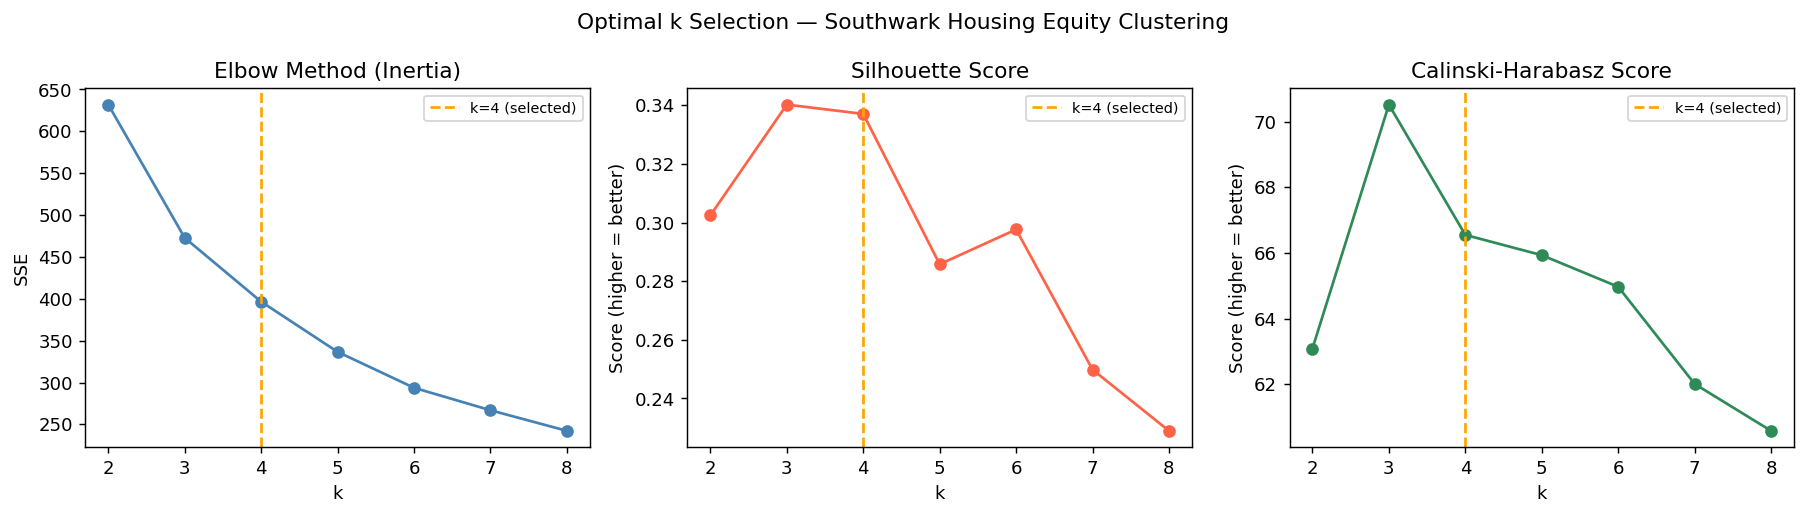


Metric summary:


,Inertia,Silhouette,Calinski-Harabasz
k,,,
2,631.881,0.302,63.087
3,472.772,0.340,70.519
4,396.544,0.337,66.549
5,336.600,0.286,65.932
6,293.701,0.298,64.969
7,266.871,0.250,62.009
8,242.295,0.229,60.579


In [55]:
K_RANGE = range(2, 9)
inertia, silhouette, calinski = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))

k_list = list(K_RANGE)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(k_list, inertia, 'o-', color='steelblue')
axes[0].set(title='Elbow Method (Inertia)', xlabel='k', ylabel='SSE')

axes[1].plot(k_list, silhouette, 'o-', color='tomato')
axes[1].set(title='Silhouette Score', xlabel='k', ylabel='Score (higher = better)')

axes[2].plot(k_list, calinski, 'o-', color='seagreen')
axes[2].set(title='Calinski-Harabasz Score', xlabel='k', ylabel='Score (higher = better)')

for ax in axes:
    ax.axvline(4, color='orange', ls='--', lw=1.5, label='k=4 (selected)')
    ax.legend(fontsize=8)

plt.suptitle('Optimal k Selection — Southwark Housing Equity Clustering', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'kmeans_k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nMetric summary:')
pd.DataFrame({'k': k_list, 'Inertia': inertia,
              'Silhouette': silhouette, 'Calinski-Harabasz': calinski}).set_index('k')

---
## 3. K-Means Clustering (k = 4)

In [56]:
K = 4
km4 = KMeans(n_clusters=K, random_state=42, n_init=50, max_iter=500)
df['kmeans_label'] = km4.fit_predict(X_scaled)

print(f'K-Means (k={K}) converged in {km4.n_iter_} iterations')
print(f'Inertia   : {km4.inertia_:.4f}')
print(f'Silhouette: {silhouette_score(X_scaled, df["kmeans_label"]):.4f}')
print('\nCluster sizes:')
print(df['kmeans_label'].value_counts().sort_index())

K-Means (k=4) converged in 6 iterations
Inertia   : 396.4905
Silhouette: 0.3303

Cluster sizes:
kmeans_label
0    98
1    21
2    30
3    24
Name: count, dtype: int64


In [57]:
# Compute cluster means on ORIGINAL (0-1) scale for interpretability
profile_raw = (
    df.groupby('kmeans_label')[FEAT_COLS + ['HEI_bayes']]
    .mean()
    .round(3)
)
profile_raw.index = [f'Cluster {i}' for i in profile_raw.index]
profile_raw.columns = FEAT_LABELS + ['HEI_bayes']

print('=== K-Means Cluster Profiles (mean of aligned vars, higher = more deprived) ===')
profile_raw

=== K-Means Cluster Profiles (mean of aligned vars, higher = more deprived) ===


,EPC\n(inv),Overcrowding,Price,Transport\n(inv),Hospital\n(inv),HEI_bayes
Cluster 0,0.370,0.629,0.116,0.855,0.724,0.587
Cluster 1,0.537,0.385,0.187,0.935,0.275,0.244
Cluster 2,0.697,0.291,0.347,0.885,0.745,0.646
Cluster 3,0.366,0.692,0.293,0.281,0.869,0.563


In [58]:
# Auto-name clusters by HEI rank (0=best equity, 3=worst equity)
hei_rank = profile_raw['HEI_bayes'].rank().astype(int) - 1
type_map_alpha = {idx: chr(65 + r) for idx, r in zip(profile_raw.index, hei_rank)}
# Map numeric labels to A/B/C/D
label_to_alpha = {i: type_map_alpha[f'Cluster {i}'] for i in range(K)}
df['cluster_type'] = df['kmeans_label'].map(label_to_alpha)

print('Cluster label → Type mapping (ranked by HEI, A=lowest HEI=best equity):')
print(label_to_alpha)
print('\nType distribution:')
print(df['cluster_type'].value_counts().sort_index())

Cluster label → Type mapping (ranked by HEI, A=lowest HEI=best equity):
{0: 'C', 1: 'A', 2: 'D', 3: 'B'}

Type distribution:
cluster_type
A    21
B    24
C    98
D    30
Name: count, dtype: int64


---
## 4. Hierarchical Clustering Validation

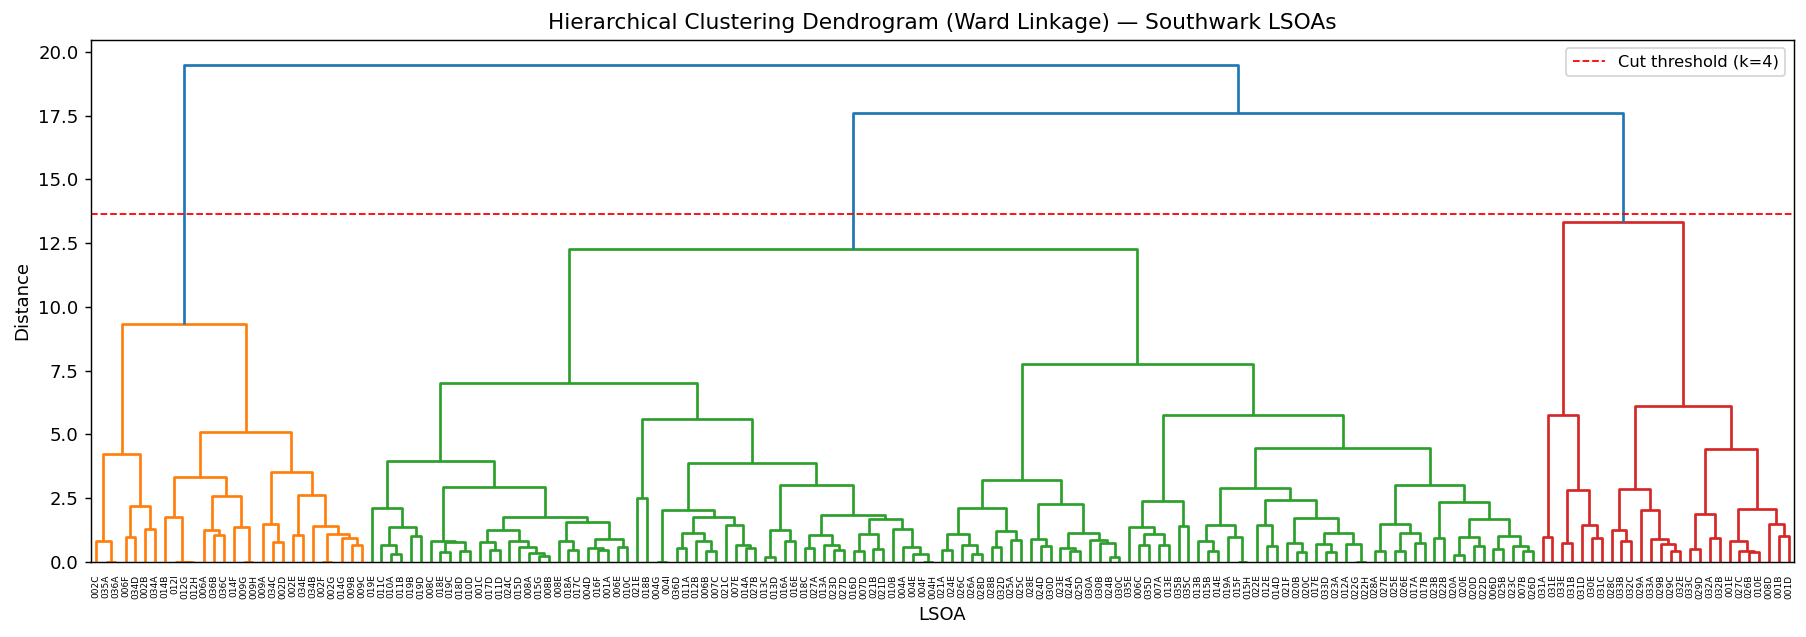

Saved → dendrogram_southwark.png


In [59]:
# Ward linkage dendrogram
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    labels=df['lsoa21nm'].str.replace('Southwark ', '', regex=False).values,
    leaf_rotation=90, leaf_font_size=5,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax
)
ax.axhline(y=0.7 * max(Z[:, 2]), color='red', ls='--', lw=1,
           label='Cut threshold (k=4)')
ax.set(title='Hierarchical Clustering Dendrogram (Ward Linkage) — Southwark LSOAs',
       xlabel='LSOA', ylabel='Distance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'dendrogram_southwark.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dendrogram_southwark.png')

In [60]:
# Hierarchical clusters at k=4 and compare with K-Means
df['hier_label'] = fcluster(Z, t=K, criterion='maxclust') - 1  # 0-indexed

# Cross-tabulation
ct = pd.crosstab(df['cluster_type'], df['hier_label'],
                 rownames=['K-Means Type'], colnames=['Hierarchical'])
print('K-Means vs Hierarchical cross-tabulation:')
print(ct)

# Agreement rate
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['kmeans_label'], df['hier_label'])
print(f'\nAdjusted Rand Index (ARI): {ari:.3f}  (1.0 = perfect agreement)')

K-Means vs Hierarchical cross-tabulation:
Hierarchical   0   1  2   3
K-Means Type               
A              0   2  0  19
B             24   0  0   0
C              4  94  0   0
D              0  23  7   0

Adjusted Rand Index (ARI): 0.590  (1.0 = perfect agreement)


---
## 5. Cluster Profile Table & Radar Chart

In [61]:
# Full profile table (with original raw variables for interpretability)
master_full = pd.read_csv(os.path.join(DATA, 'master_southwark_hei.csv'))
master_full = master_full.drop_duplicates(subset=['lsoa21cd']).reset_index(drop=True)

# Add cluster type
df_typed = df[['lsoa21cd','cluster_type']]
master_full = master_full.merge(df_typed, on='lsoa21cd', how='left')

RAW_PROFILE_COLS = {
    'avg_epc_rating_num'  : 'EPC Rating (1-7)',
    'overcrowding_idx'    : 'Overcrowding Index',
    'median_house_price'  : 'Median Price (£)',
    'transport_ptai'      : 'PTAI Score',
    'hospital'            : 'Hospital Access',
    'avg_floor_area'      : 'Avg Floor Area (m²)',
    'avg_rooms'           : 'Avg Rooms',
    'HEI_bayes'             : 'HEI (Bayesian)',
}

profile_table = (
    master_full.groupby('cluster_type')[list(RAW_PROFILE_COLS.keys())]
    .mean()
    .round(3)
    .rename(columns=RAW_PROFILE_COLS)
)
profile_table.index.name = 'Cluster Type'

print('=== Cluster Profile Table (raw variable means) ===')
profile_table

=== Cluster Profile Table (raw variable means) ===


,EPC Rating (1-7),Overcrowding Index,Median Price (£),PTAI Score,Hospital Access,Avg Floor Area (m²),Avg Rooms,HEI (Bayesian)
Cluster Type,,,,,,,,
A,4.376,0.003,529395.905,10.591,2.487,85.812,3.971,0.244
B,4.596,0.004,671215.783,74.583,0.876,68.642,3.339,0.563
C,4.564,0.004,432794.539,18.264,1.281,69.228,3.562,0.587
D,4.192,0.003,737375.000,15.410,1.209,100.071,4.093,0.646


In [62]:
# Count and HEI range per cluster
size_table = master_full.groupby('cluster_type').agg(
    n_lsoa   = ('lsoa21cd', 'count'),
    hei_min  = ('HEI_bayes',  'min'),
    hei_max  = ('HEI_bayes',  'max'),
    hei_mean = ('HEI_bayes',  'mean'),
).round(3)
print('\nCluster size & HEI range:')
print(size_table)


Cluster size & HEI range:
              n_lsoa  hei_min  hei_max  hei_mean
cluster_type                                    
A                 21    0.015    0.454     0.244
B                 24    0.416    0.730     0.563
C                 98    0.267    0.968     0.587
D                 30    0.383    0.812     0.646


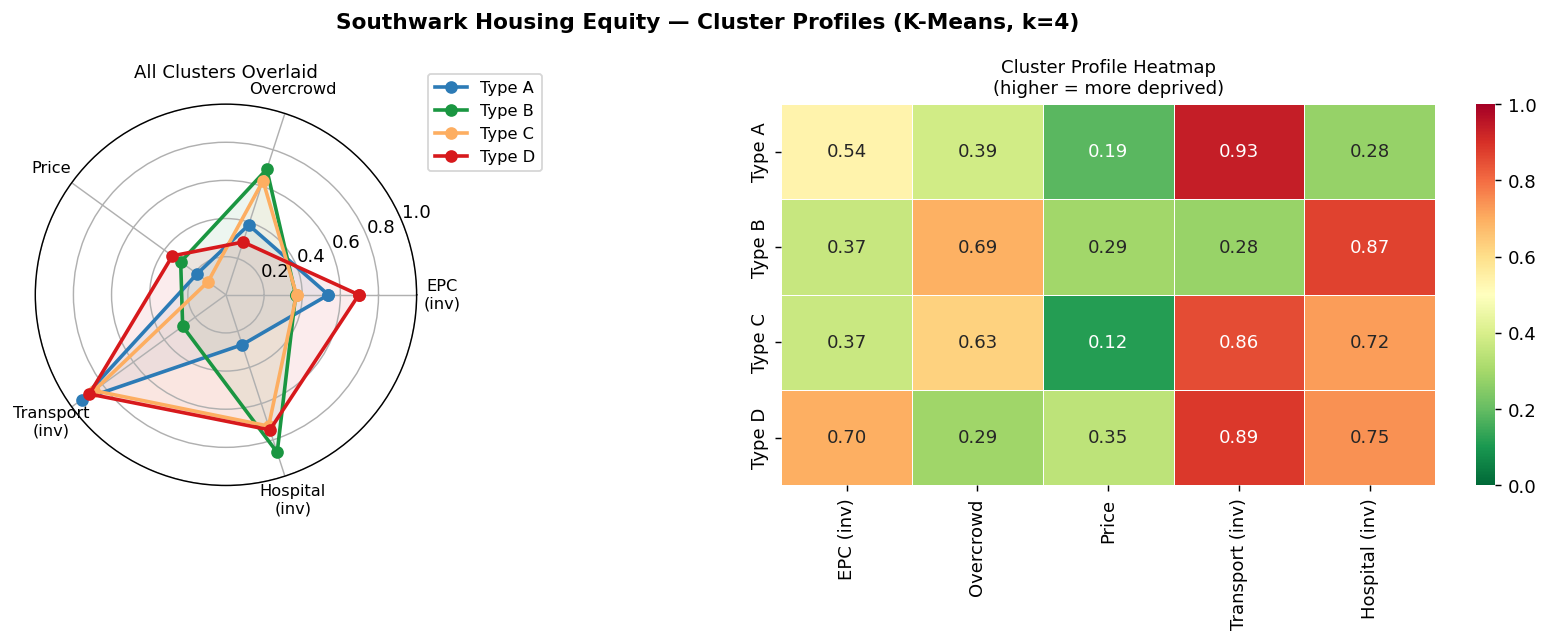

Saved → cluster_profile_radar_heatmap.png


In [63]:
# Radar chart (spider plot) of cluster profiles
radar_cols = FEAT_COLS
radar_labels = ['EPC\n(inv)', 'Overcrowd', 'Price', 'Transport\n(inv)', 'Hospital\n(inv)']

radar_data = df.groupby('cluster_type')[radar_cols].mean()

N = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close polygon

CLUSTER_COLORS = {'A': '#2c7bb6', 'B': '#1a9641', 'C': '#fdae61', 'D': '#d7191c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw=dict(polar=True))

# Individual subplots per cluster
ax = axes[0]
for ctype, row in radar_data.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', lw=2,
            color=CLUSTER_COLORS.get(ctype, 'grey'), label=f'Type {ctype}')
    ax.fill(angles, vals, alpha=0.08, color=CLUSTER_COLORS.get(ctype, 'grey'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('All Clusters Overlaid', fontsize=10, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

# Heatmap alternative on right
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2)

heat_data = radar_data.copy()
heat_data.columns = ['EPC (inv)', 'Overcrowd', 'Price', 'Transport (inv)', 'Hospital (inv)']
heat_data.index   = [f'Type {c}' for c in heat_data.index]

sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=1, linewidths=0.5,
            annot_kws={'size': 10}, ax=ax2)
ax2.set_title('Cluster Profile Heatmap\n(higher = more deprived)', fontsize=10)
ax2.set_xlabel('')

plt.suptitle('Southwark Housing Equity — Cluster Profiles (K-Means, k=4)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'cluster_profile_radar_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cluster_profile_radar_heatmap.png')

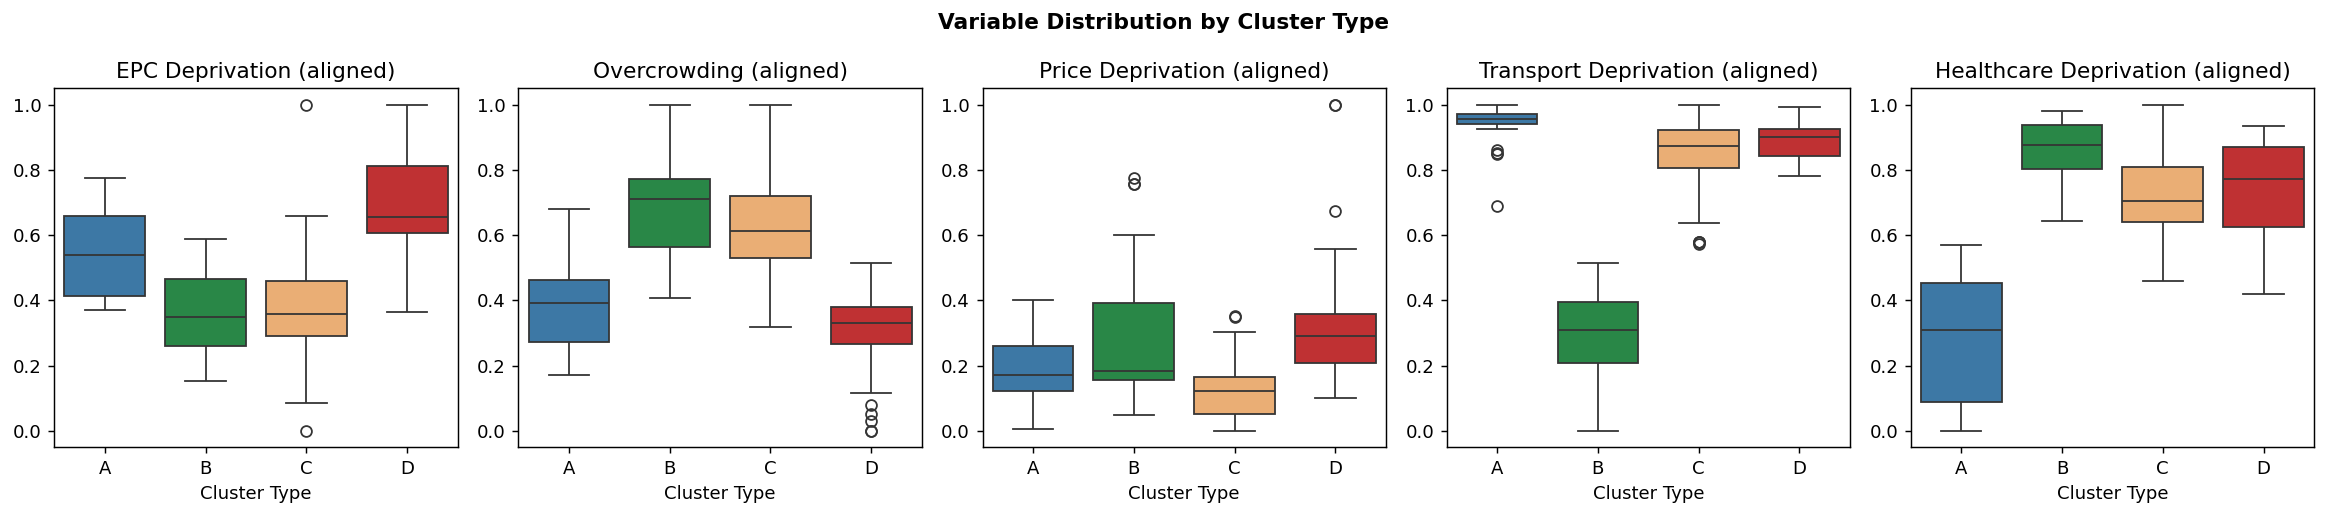

In [64]:
# Box plots: variable distribution by cluster
plot_vars = {
    'avg_epc_rating_num_al': 'EPC Deprivation (aligned)',
    'overcrowding_proxy_al': 'Overcrowding (aligned)',
    'median_house_price_al': 'Price Deprivation (aligned)',
    'transport_ptai_al'    : 'Transport Deprivation (aligned)',
    'hospital_al'          : 'Healthcare Deprivation (aligned)',
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
palette = {'A':'#2c7bb6','B':'#1a9641','C':'#fdae61','D':'#d7191c'}

for ax, (col, label) in zip(axes, plot_vars.items()):
    sns.boxplot(data=df, x='cluster_type', y=col,
                palette=palette, order=['A','B','C','D'], ax=ax)
    ax.set(title=label, xlabel='Cluster Type', ylabel='')
    ax.set_xticklabels(['A','B','C','D'])

plt.suptitle('Variable Distribution by Cluster Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'cluster_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Spatial Map of Cluster Types

In [65]:
# Load shapefile
gdf = gpd.read_file(os.path.join(SHP_DIR, 'Southwark.shp')).to_crs(epsg=27700)

# Merge cluster labels
shp_extra = set(gdf.columns) - {'geometry', 'lsoa21cd'}
df_merge  = df[['lsoa21cd','cluster_type','kmeans_label','HEI_bayes']].copy()
geo = gdf.merge(df_merge, on='lsoa21cd', how='left')

# Also bring in LISA labels from RQ3 if available
lisa_path = os.path.join(DATA, 'southwark_lisa.csv')
if os.path.exists(lisa_path):
    lisa = pd.read_csv(lisa_path)[['lsoa21cd','lisa_label']]\
              .drop_duplicates(subset=['lsoa21cd'])
    geo = geo.merge(lisa, on='lsoa21cd', how='left')
    print('LISA labels merged.')

print(f'GeoDataFrame: {geo.shape}')
print('Cluster type counts:', geo['cluster_type'].value_counts().to_dict())

LISA labels merged.
GeoDataFrame: (173, 11)
Cluster type counts: {'C': 98, 'D': 30, 'B': 24, 'A': 21}


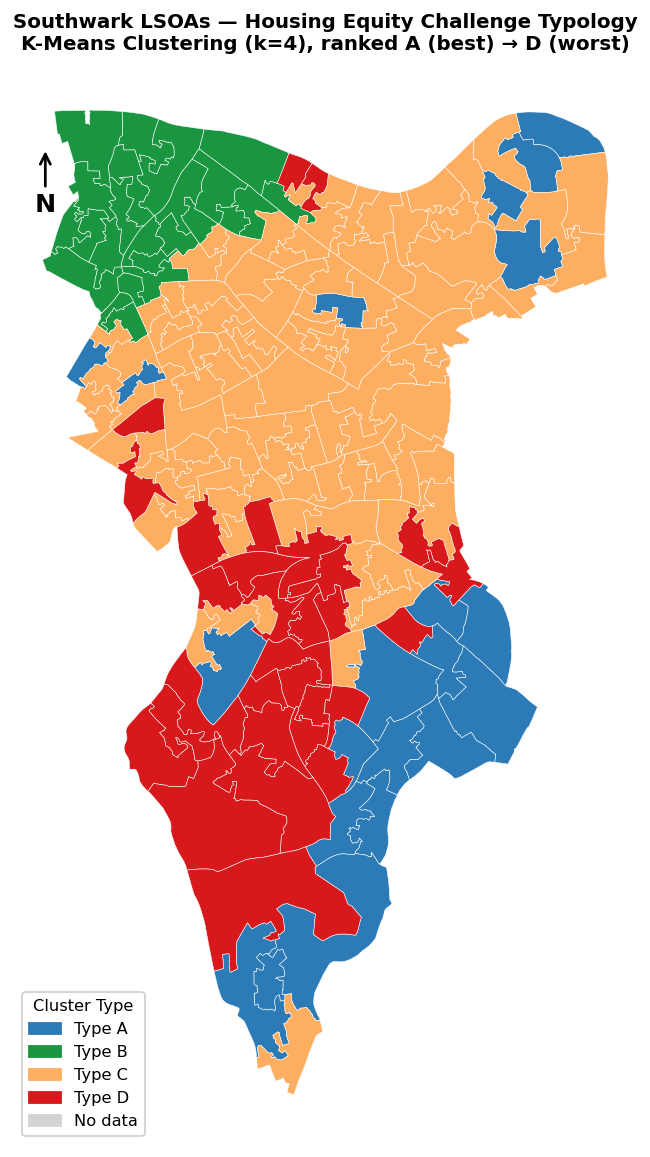

Saved → cluster_map_southwark.png


In [66]:
CLUSTER_COLORS = {
    'A': '#2c7bb6',   # blue  — best equity
    'B': '#1a9641',   # green
    'C': '#fdae61',   # orange
    'D': '#d7191c',   # red   — worst equity
}

fig, ax = plt.subplots(figsize=(9, 9))

for ctype, color in CLUSTER_COLORS.items():
    subset = geo[geo['cluster_type'] == ctype]
    subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3)

# Missing in grey
geo[geo['cluster_type'].isna()].plot(ax=ax, color='lightgrey',
                                      edgecolor='white', linewidth=0.3)

# Legend
# (names will be updated after interpreting profiles — placeholders here)
patches = [mpatches.Patch(color=CLUSTER_COLORS[t], label=f'Type {t}')
           for t in ['A','B','C','D']]
patches.append(mpatches.Patch(color='lightgrey', label='No data'))
ax.legend(handles=patches, loc='lower left', fontsize=9,
          title='Cluster Type', title_fontsize=9, framealpha=0.9)

ax.annotate('N', xy=(0.05, 0.92), xytext=(0.05, 0.86),
            xycoords='axes fraction', textcoords='axes fraction',
            fontsize=14, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5))
ax.set_title('Southwark LSOAs — Housing Equity Challenge Typology\n'
             'K-Means Clustering (k=4), ranked A (best) → D (worst)',
             fontsize=11, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DATA, 'cluster_map_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cluster_map_southwark.png')

---
## 7. Policy Interpretation Table

> Run the profile cells above first; then fill in the interpretation based on actual cluster means.

In [67]:
# Auto-generate interpretation based on cluster profile relative to overall mean
overall_mean = df[FEAT_COLS].mean()
cluster_mean = df.groupby('cluster_type')[FEAT_COLS].mean()

# Deviation from mean (+ = above mean = more deprived on that dimension)
deviation = cluster_mean.subtract(overall_mean)
deviation.columns = FEAT_LABELS

print('=== Cluster deviation from overall mean (+ = more deprived, - = less deprived) ===')
deviation.round(3)

=== Cluster deviation from overall mean (+ = more deprived, - = less deprived) ===


,EPC\n(inv),Overcrowding,Price,Transport\n(inv),Hospital\n(inv)
cluster_type,,,,,
A,0.091,-0.164,-0.002,0.145,-0.418
B,-0.081,0.143,0.104,-0.510,0.176
C,-0.076,0.079,-0.073,0.065,0.031
D,0.250,-0.258,0.158,0.095,0.052


In [68]:
# Identify dominant deprivation dimension per cluster
def dominant_dims(row, threshold=0.05):
    high = [FEAT_LABELS[i] for i, v in enumerate(row) if v > threshold]
    low  = [FEAT_LABELS[i] for i, v in enumerate(row) if v < -threshold]
    return pd.Series({'High deprivation on': ', '.join(high) or '—',
                      'Low deprivation on' : ', '.join(low)  or '—'})

dim_table = deviation.apply(dominant_dims, axis=1)

# HEI summary
hei_summary = master_full.groupby('cluster_type')['HEI_bayes'].agg(['mean','count']).round(3)
hei_summary.columns = ['Mean HEI', 'N LSOAs']

policy_table = dim_table.join(hei_summary)
print('=== Policy Interpretation Input ===')
policy_table

=== Policy Interpretation Input ===


,High deprivation on,Low deprivation on,Mean HEI,N LSOAs
cluster_type,,,,
A,"EPC\n(inv), Transport\n(inv)","Overcrowding, Hospital\n(inv)",0.244,21
B,"Overcrowding, Price, Hospital\n(inv)","EPC\n(inv), Transport\n(inv)",0.563,24
C,"Overcrowding, Transport\n(inv)","EPC\n(inv), Price",0.587,98
D,"EPC\n(inv), Price, Transport\n(inv), Hospital\...",Overcrowding,0.646,30


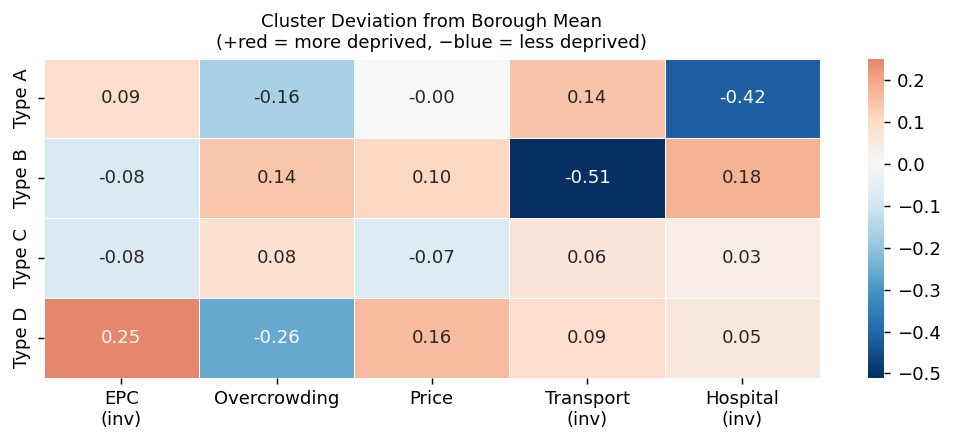

In [69]:
# Heatmap of deviations
fig, ax = plt.subplots(figsize=(8, 3.5))
dev_plot = deviation.copy()
dev_plot.index = [f'Type {c}' for c in dev_plot.index]

sns.heatmap(dev_plot, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title('Cluster Deviation from Borough Mean\n(+red = more deprived, −blue = less deprived)',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'cluster_deviation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Geographically Weighted PCA (GWPCA)

GWPCA performs local PCA at each LSOA using a spatially-decaying bisquare kernel,
revealing **spatial non-stationarity** in the factor structure of housing equity indicators.
Unlike global PCA / Bayesian FA (which yield a single loading vector), GWPCA produces
a unique loading per LSOA — identifying *where* each deprivation dimension dominates locally.

| Output | Description |
|---|---|
| `gw_load_[var]` | Local PC1 loading for each indicator |
| `gw_dominant` | Indicator with highest |loading| at that LSOA |
| `gw_var_exp` | Local proportion of variance explained by PC1 |
| `gw_score` | Local PC1 projection score (spatially varying composite index) |

Bandwidth: adaptive bisquare kernel; optimal k selected by leave-one-out reconstruction CV.

GWPCA input: N=173 LSOAs,  J=5 indicators
Running LOO-CV over k ∈ [17, 95] …
  k= 92  LOO_err=0.06662
Optimal bandwidth: k = 17  (10% of N)


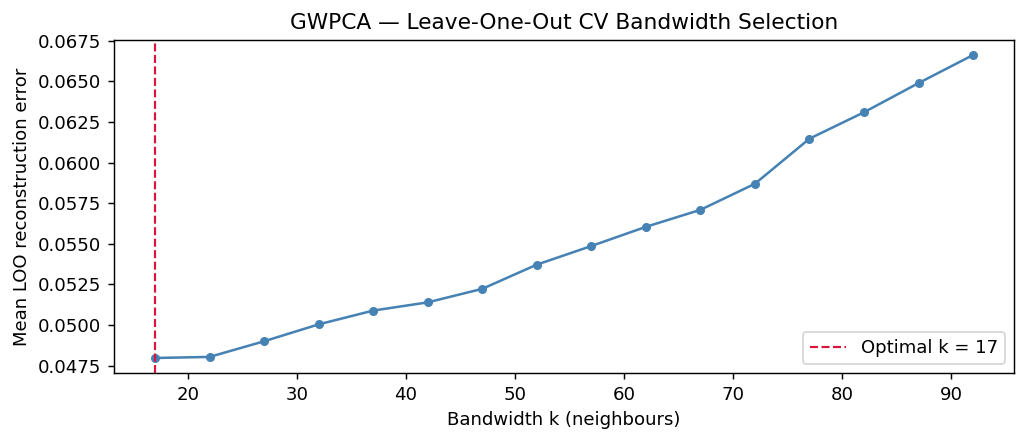

In [70]:
# --- 8.1  GWPCA — Function & Bandwidth Selection (LOO-CV) ---
from scipy.spatial.distance import cdist

def gwpca(X, coords, bw_k, global_ref=None):
    """
    Geographically Weighted PCA (K=1, bisquare adaptive kernel).

    At each focal LSOA i, build the kernel-weighted local covariance matrix
    and extract PC1.  Signs are aligned to the global PC1 for comparability.

    Parameters
    ----------
    X          : (N, J) normalised, direction-aligned indicator matrix
    coords     : (N, 2) projected coordinates in metres (EPSG:27700)
    bw_k       : adaptive bandwidth — index of k-th nearest neighbour
    global_ref : (J,) global PC1 loading vector; computed internally if None

    Returns
    -------
    scores   : (N,)   local PC1 score at focal point
    loadings : (N, J) local PC1 loadings (sign-aligned to global PC1)
    var_exp  : (N,)   proportion of variance explained by local PC1
    loo_err  : float  mean LOO reconstruction error (used for CV)
    """
    N, J = X.shape
    D = cdist(coords, coords)              # (N, N) pairwise Euclidean distances

    # Global PC1 for sign reference (eigh returns ascending eigenvalues)
    if global_ref is None:
        Xc0 = X - X.mean(0)
        _, evecs0 = np.linalg.eigh(Xc0.T @ Xc0 / N)
        global_ref = evecs0[:, -1]

    scores   = np.zeros(N)
    loadings = np.zeros((N, J))
    var_exp  = np.zeros(N)
    loo_sq   = np.zeros(N)

    for i in range(N):
        d  = D[i]
        bw = np.sort(d)[bw_k]            # k-th NN distance as bandwidth
        u  = d / bw
        w  = np.where(u < 1.0, (1 - u**2)**2, 0.0)   # bisquare
        w  = np.maximum(w, 1e-12)

        ws   = w.sum()
        xbar = (w[:, None] * X).sum(0) / ws    # weighted centroid (J,)
        Xc   = X - xbar                         # centred (N, J)

        # Weighted covariance (J×J)
        Wcov = (w[:, None] * Xc).T @ Xc / ws

        # Eigendecomposition
        evals, evecs = np.linalg.eigh(Wcov)
        idx   = np.argsort(evals)[::-1]
        evals = evals[idx]; evecs = evecs[:, idx]

        pc1 = evecs[:, 0]
        if np.dot(pc1, global_ref) < 0:        # sign alignment
            pc1 = -pc1

        loadings[i] = pc1
        scores[i]   = Xc[i] @ pc1
        tv          = np.sum(evals[evals > 0])
        var_exp[i]  = evals[0] / tv if tv > 0 else 0.0

        # LOO: drop focal point, refit with remaining points
        mask   = np.ones(N, bool); mask[i] = False
        ws_l   = w[mask].sum()
        xbar_l = (w[mask, None] * X[mask]).sum(0) / ws_l
        Xc_l   = X[mask] - xbar_l
        Wcov_l = (w[mask, None] * Xc_l).T @ Xc_l / ws_l
        _, vc_l = np.linalg.eigh(Wcov_l)
        pc1_l   = vc_l[:, -1]
        if np.dot(pc1_l, global_ref) < 0:
            pc1_l = -pc1_l
        xi_c      = X[i] - xbar_l
        recon     = (xi_c @ pc1_l) * pc1_l
        loo_sq[i] = np.sum((xi_c - recon) ** 2)

    return scores, loadings, var_exp, float(loo_sq.mean())


# ── Prepare spatial data ──────────────────────────────────────────────────────
# Merge FEAT_COLS into geo if not already present
if not all(c in geo.columns for c in FEAT_COLS):
    _feat_extra = df[['lsoa21cd'] + FEAT_COLS].drop_duplicates('lsoa21cd')
    geo = geo.merge(_feat_extra, on='lsoa21cd', how='left')

geo_gw = geo.dropna(subset=FEAT_COLS).copy().reset_index(drop=True)
coords = np.array([[g.centroid.x, g.centroid.y] for g in geo_gw.geometry])
X_gw   = geo_gw[FEAT_COLS].values
N_gw   = X_gw.shape[0]

# Global PC1 reference
Xc0 = X_gw - X_gw.mean(0)
_, evecs0 = np.linalg.eigh(Xc0.T @ Xc0 / N_gw)
global_pc1 = evecs0[:, -1]

print(f'GWPCA input: N={N_gw} LSOAs,  J={X_gw.shape[1]} indicators')

# ── Leave-one-out bandwidth CV ────────────────────────────────────────────────
k_min = max(X_gw.shape[1] + 3, int(N_gw * 0.10))
k_max = int(N_gw * 0.55)
k_cands = list(range(k_min, k_max + 1, 5))

print(f'Running LOO-CV over k ∈ [{k_min}, {k_max}] …')
cv_errors = []
for k in k_cands:
    _, _, _, err = gwpca(X_gw, coords, bw_k=k, global_ref=global_pc1)
    cv_errors.append(err)
    print(f'  k={k:3d}  LOO_err={err:.5f}', end='\r')

best_k = k_cands[int(np.argmin(cv_errors))]
print(f'\nOptimal bandwidth: k = {best_k}  ({100*best_k/N_gw:.0f}% of N)')

# Bandwidth sensitivity plot
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(k_cands, cv_errors, 'o-', color='steelblue', ms=4, lw=1.4)
ax.axvline(best_k, color='crimson', ls='--', lw=1.2, label=f'Optimal k = {best_k}')
ax.set_xlabel('Bandwidth k (neighbours)'); ax.set_ylabel('Mean LOO reconstruction error')
ax.set_title('GWPCA — Leave-One-Out CV Bandwidth Selection')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gwpca_bandwidth_cv.png'), dpi=150, bbox_inches='tight')
plt.show()

Running GWPCA  (k=17, bisquare adaptive) …
Mean local PC1 variance explained: 0.609  (range 0.356–0.813)

Dominant dimension frequency:
gw_dominant
Hospital\n(inv)     46
EPC\n(inv)          42
Overcrowding        36
Price               30
Transport\n(inv)    19


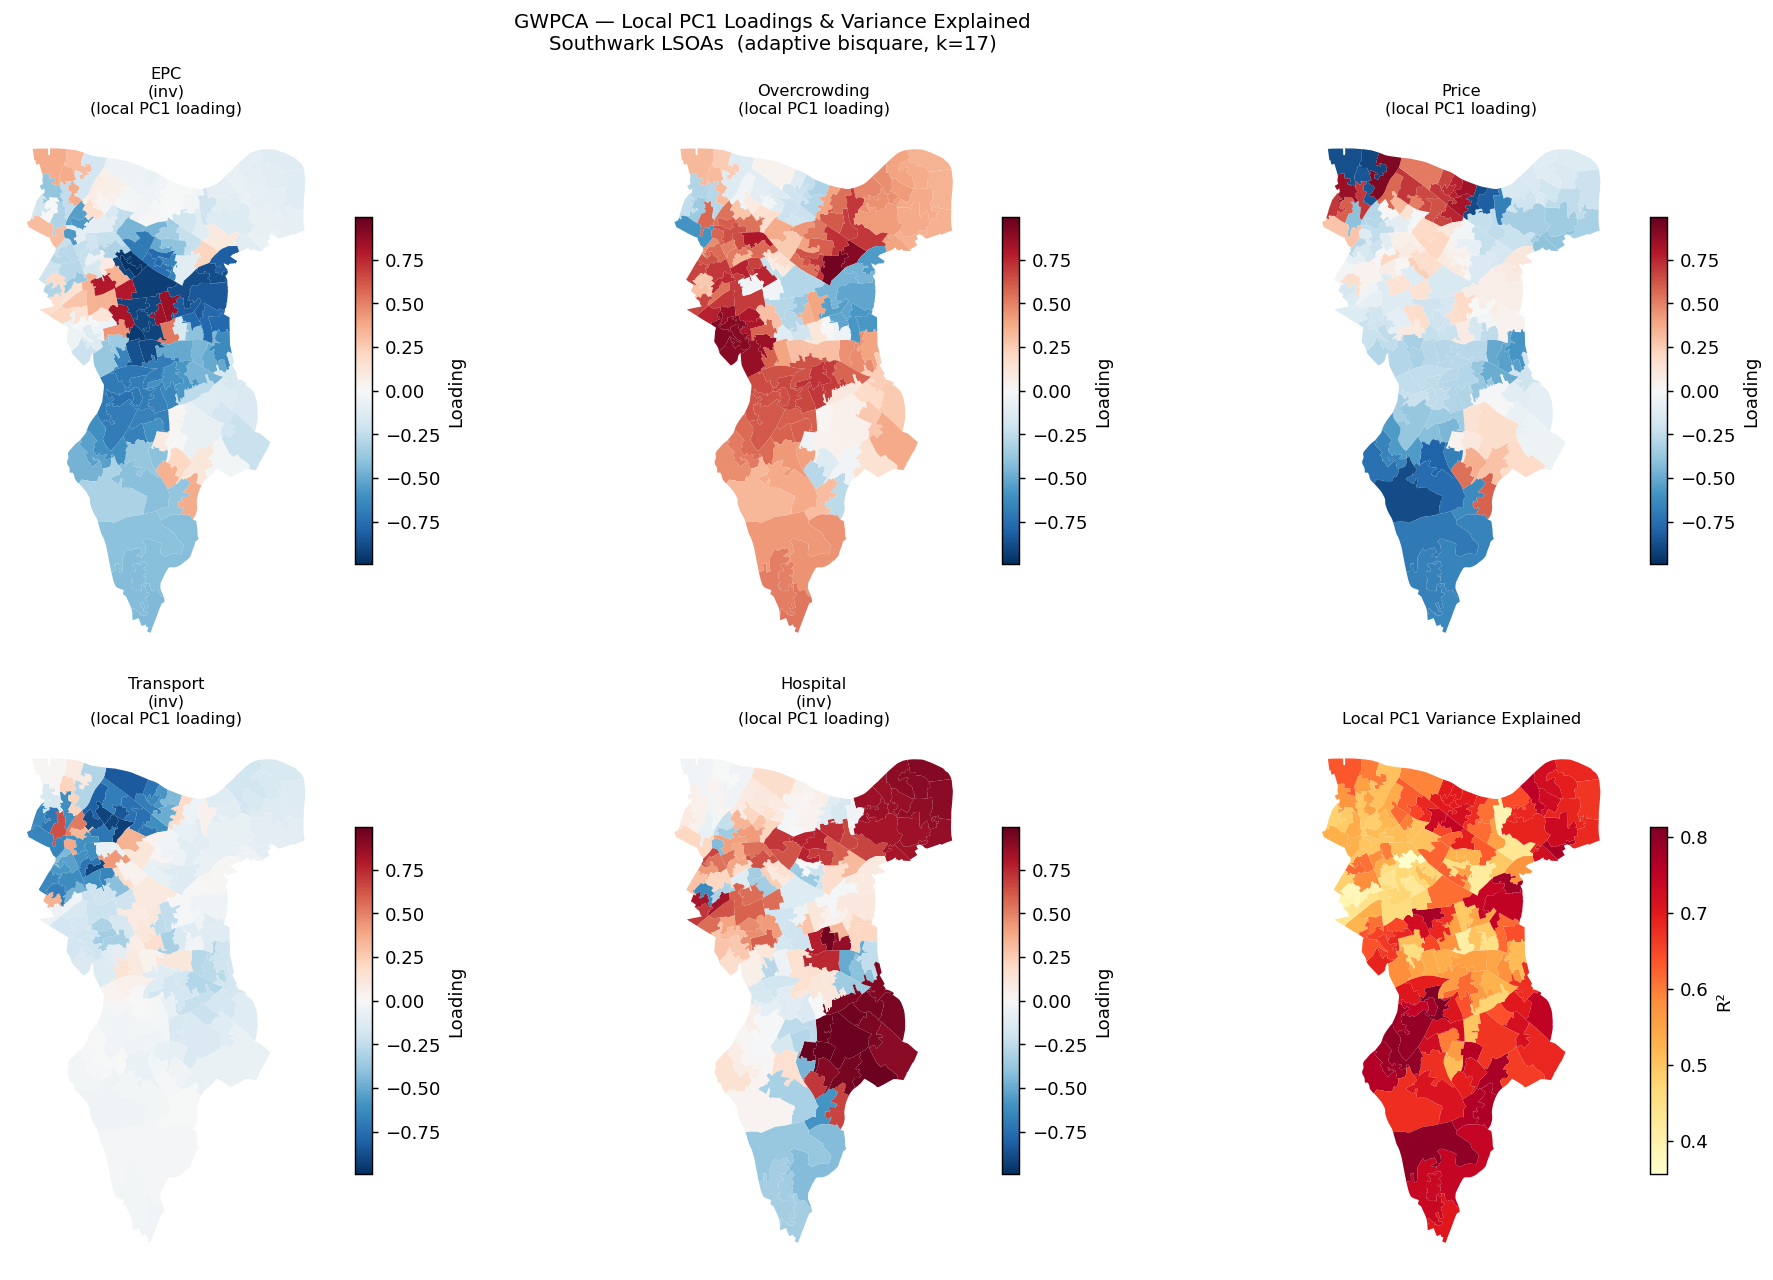

In [71]:
# --- 8.2  Run GWPCA + Local Loadings Maps ---
print(f'Running GWPCA  (k={best_k}, bisquare adaptive) …')
gw_scores, gw_loadings, gw_var_exp, _ = gwpca(X_gw, coords, bw_k=best_k,
                                                global_ref=global_pc1)

# Store results in geo_gw
for j, col in enumerate(FEAT_COLS):
    geo_gw[f'gw_load_{col}'] = gw_loadings[:, j]

geo_gw['gw_var_exp'] = gw_var_exp
geo_gw['gw_score']   = gw_scores

# Dominant dimension per LSOA
dom_idx             = np.abs(gw_loadings).argmax(axis=1)
geo_gw['gw_dominant'] = [FEAT_LABELS[i] for i in dom_idx]

print(f'Mean local PC1 variance explained: {gw_var_exp.mean():.3f}  '
      f'(range {gw_var_exp.min():.3f}–{gw_var_exp.max():.3f})')
print('\nDominant dimension frequency:')
print(geo_gw['gw_dominant'].value_counts().to_string())

# ── 6-panel figure: 5 × loading maps + local R² ──────────────────────────────
load_cols   = [f'gw_load_{c}' for c in FEAT_COLS]
panel_titles = [f'{lb}\n(local PC1 loading)' for lb in FEAT_LABELS]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.ravel()

# Symmetric colour scale for loadings
vmax = max(np.abs(geo_gw[load_cols].values).max(), 0.01)

for ax, col, title in zip(axes_flat[:5], load_cols, panel_titles):
    geo_gw.plot(column=col, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                legend=True, ax=ax,
                legend_kwds={'shrink': 0.65, 'label': 'Loading'},
                missing_kwds={'color': 'lightgrey'})
    ax.set_title(title, fontsize=9); ax.axis('off')

# Panel 6: local variance explained
geo_gw.plot(column='gw_var_exp', cmap='YlOrRd', legend=True, ax=axes_flat[5],
            legend_kwds={'shrink': 0.65, 'label': 'R²'},
            missing_kwds={'color': 'lightgrey'})
axes_flat[5].set_title(f'Local PC1 Variance Explained', fontsize=9)
axes_flat[5].axis('off')

fig.suptitle(f'GWPCA — Local PC1 Loadings & Variance Explained\n'
             f'Southwark LSOAs  (adaptive bisquare, k={best_k})', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gwpca_local_loadings.png'), dpi=150, bbox_inches='tight')
plt.show()

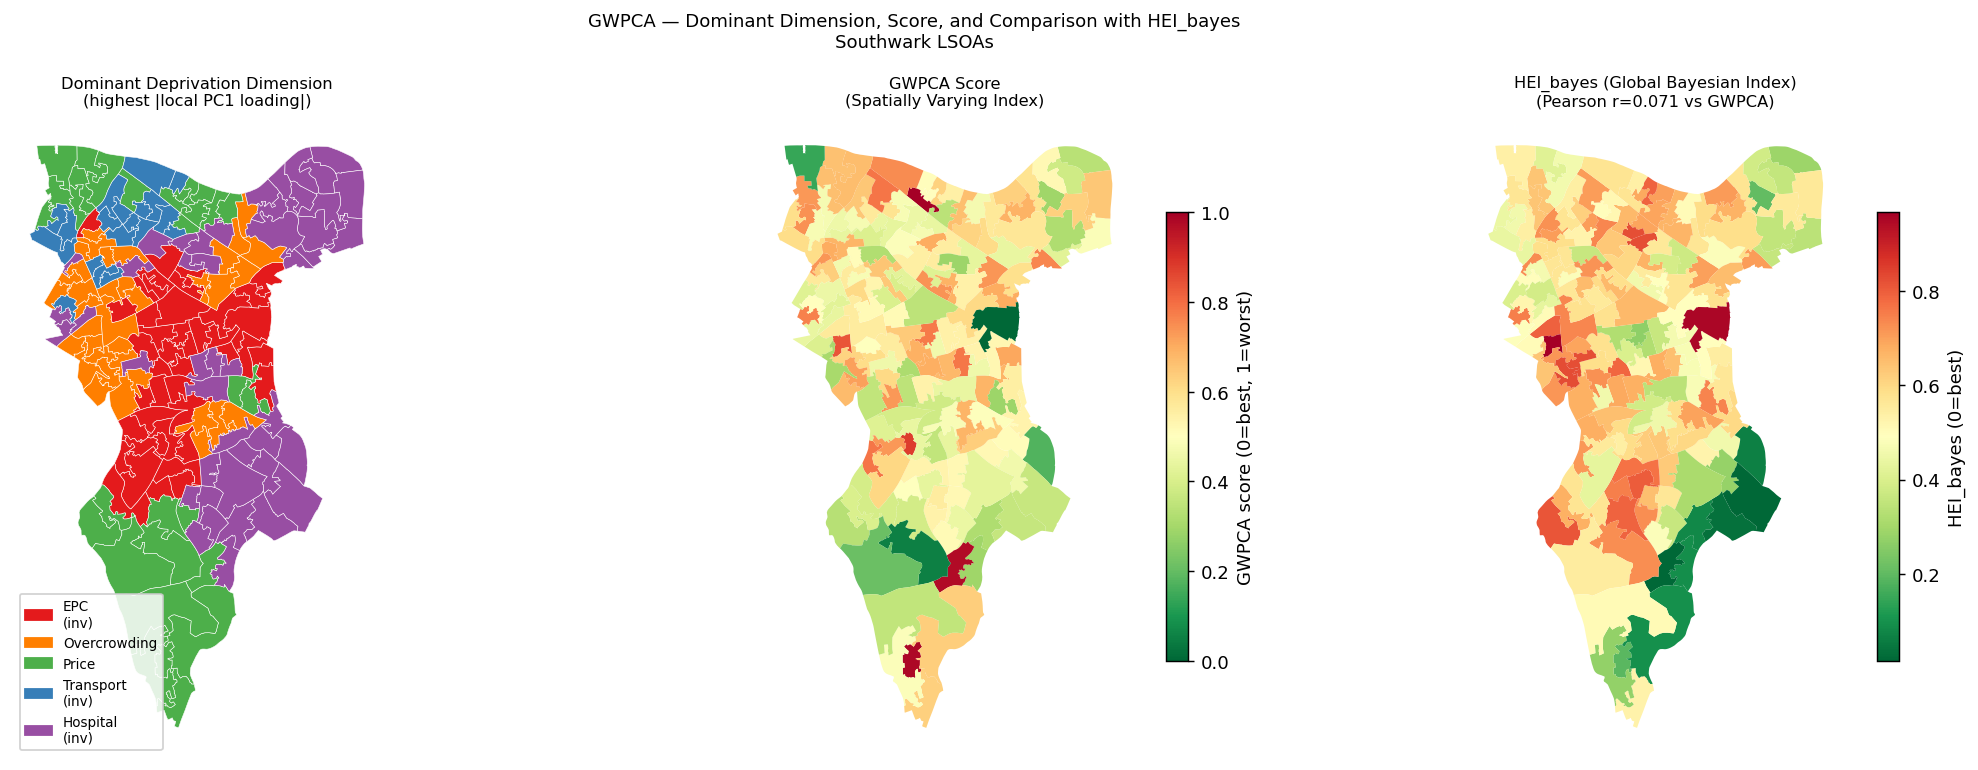

=== GWPCA Dominant Dimension × K-Means Cluster Type ===
Dominant Dimension  EPC\n(inv)  Hospital\n(inv)  Overcrowding  Price  \
Cluster Type                                                           
A                            1               14             2      4   
B                            1                1             4      9   
C                           30               26            25      8   
D                           10                5             5      9   

Dominant Dimension  Transport\n(inv)  
Cluster Type                          
A                                  0  
B                                  9  
C                                  9  
D                                  1  

(% of LSOAs within each cluster type):
Dominant Dimension  EPC\n(inv)  Hospital\n(inv)  Overcrowding  Price  \
Cluster Type                                                           
A                        4.800           66.700         9.500 19.000   
B                    

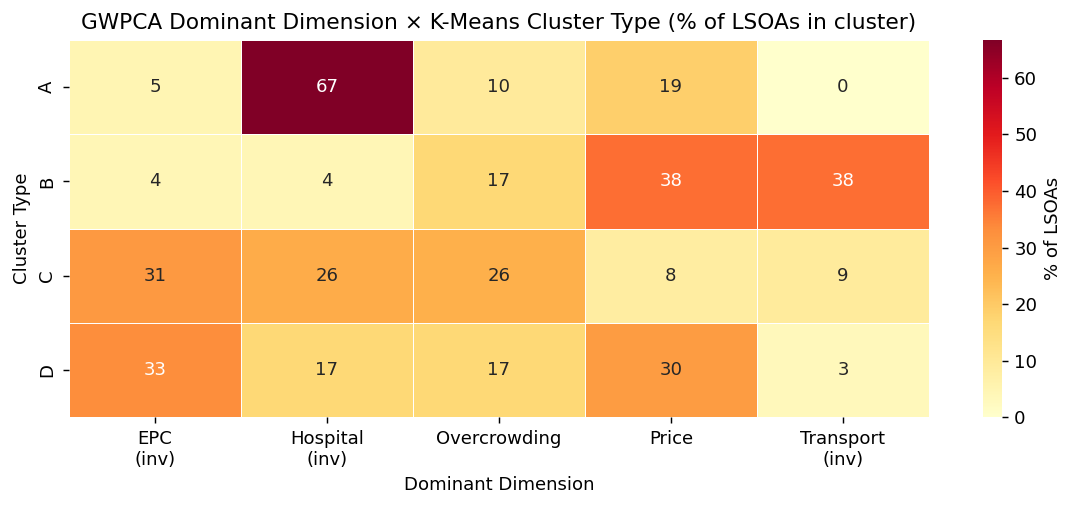


Interpretation: rows show which deprivation dimensions characterise each cluster locally,
validating the global K-means typology with spatially-explicit evidence.


In [72]:
# --- 8.3  Dominant Dimension Map, GWPCA Score & Cluster Cross-tabulation ---
import matplotlib.patches as mpatches

DIM_COLORS = {
    FEAT_LABELS[0]: '#e41a1c',   # EPC        → red
    FEAT_LABELS[1]: '#ff7f00',   # Overcrowd  → orange
    FEAT_LABELS[2]: '#4daf4a',   # Price      → green
    FEAT_LABELS[3]: '#377eb8',   # Transport  → blue
    FEAT_LABELS[4]: '#984ea3',   # Hospital   → purple
}

# Ensure cluster_type is in geo_gw
if 'cluster_type' not in geo_gw.columns:
    _ct = df[['lsoa21cd','cluster_type']].drop_duplicates('lsoa21cd')
    geo_gw = geo_gw.merge(_ct, on='lsoa21cd', how='left')

# MinMax-scale GWPCA score to [0,1] (higher = more deprived, aligned with HEI_bayes)
gw_s = geo_gw['gw_score']
geo_gw['gw_score_mm'] = (gw_s - gw_s.min()) / (gw_s.max() - gw_s.min())

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# (a) Dominant deprivation dimension
for dim, color in DIM_COLORS.items():
    sub = geo_gw[geo_gw['gw_dominant'] == dim]
    if len(sub):
        sub.plot(ax=axes[0], color=color, edgecolor='white', linewidth=0.3)
geo_gw[geo_gw['gw_dominant'].isna()].plot(ax=axes[0], color='lightgrey',
                                             edgecolor='white', lw=0.3)
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in DIM_COLORS.items()]
axes[0].legend(handles=legend_patches, fontsize=7.5, loc='lower left', framealpha=0.85)
axes[0].set_title('Dominant Deprivation Dimension\n(highest |local PC1 loading|)', fontsize=9)
axes[0].axis('off')

# (b) GWPCA score (spatially varying composite index)
geo_gw.plot(column='gw_score_mm', cmap='RdYlGn_r', legend=True, ax=axes[1],
            legend_kwds={'shrink': 0.7, 'label': 'GWPCA score (0=best, 1=worst)'},
            missing_kwds={'color': 'lightgrey'})
axes[1].set_title('GWPCA Score\n(Spatially Varying Index)', fontsize=9)
axes[1].axis('off')

# (c) HEI_bayes side-by-side
if 'HEI_bayes' in geo_gw.columns:
    valid = geo_gw.dropna(subset=['gw_score_mm','HEI_bayes'])
    r_val = np.corrcoef(valid['gw_score_mm'], valid['HEI_bayes'])[0, 1]
    geo_gw.plot(column='HEI_bayes', cmap='RdYlGn_r', legend=True, ax=axes[2],
                legend_kwds={'shrink': 0.7, 'label': 'HEI_bayes (0=best)'},
                missing_kwds={'color': 'lightgrey'})
    axes[2].set_title(f'HEI_bayes (Global Bayesian Index)\n'
                       f'(Pearson r={r_val:.3f} vs GWPCA)', fontsize=9)
    axes[2].axis('off')

fig.suptitle('GWPCA — Dominant Dimension, Score, and Comparison with HEI_bayes\nSouthwark LSOAs',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'gwpca_dominant_score.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Cross-tabulation: GWPCA dominant dimension × K-means cluster type ────────
if 'cluster_type' in geo_gw.columns:
    ct = pd.crosstab(geo_gw['cluster_type'], geo_gw['gw_dominant'],
                     rownames=['Cluster Type'], colnames=['Dominant Dimension'])
    print('=== GWPCA Dominant Dimension × K-Means Cluster Type ===')
    print(ct)

    ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
    print('\n(% of LSOAs within each cluster type):')
    print(ct_pct)

    # Heatmap
    fig2, ax2 = plt.subplots(figsize=(9, 4))
    sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, annot_kws={'size': 10},
                cbar_kws={'label': '% of LSOAs'}, ax=ax2)
    ax2.set_title('GWPCA Dominant Dimension × K-Means Cluster Type (% of LSOAs in cluster)')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'gwpca_cluster_crosstab.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print('\nInterpretation: rows show which deprivation dimensions characterise each cluster locally,')
    print('validating the global K-means typology with spatially-explicit evidence.')

---
## 9. Spatially Constrained Clustering: SKATER & REDCAP

Both methods enforce **spatial contiguity** — every resulting region is a connected
set of adjacent LSOAs.  This is a key distinction from K-means, which can produce
spatially fragmented clusters.

| Method | Algorithm | Key property |
|---|---|---|
| **SKATER** | Minimum Spanning Tree edge removal | Greedy, globally optimal per step |
| **REDCAP** | Constrained Ward agglomeration | Bottom-up, adjacent-only merges |

Both are run with **k = 4** to match the K-means partition.
Labels are aligned to K-means by mean HEI_bayes rank (A = best equity, D = worst)
so colour maps are directly comparable.

In [73]:
# --- 9.1  SKATER & REDCAP — Pure NumPy/SciPy/libpysal Implementations ---
from libpysal.weights import Queen
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components as sp_cc
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist as _cdist
from sklearn.metrics import adjusted_rand_score

try:
    from spopt.region import Skater as _SpoptSkater, RedCap as _SpoptRedCap
    SPOPT_AVAILABLE = True
    print('spopt available — using spopt implementations.')
except ImportError:
    SPOPT_AVAILABLE = False
    print('spopt not available — using built-in implementations.')


# ── Helper: guarantee connected spatial adjacency ─────────────────────────────
def ensure_connected_adj(W_sp, coords, N):
    """
    Return an adjacency dict {i: set(neighbours)} that is guaranteed to be
    a single connected component.  Any Queen-disconnected islands (e.g. Thames
    riverside LSOAs) are bridged to their geographically nearest neighbour in
    another component.  Returns the dict and the number of bridges added.
    """
    adj = {i: set(W_sp.getrow(i).nonzero()[1]) - {i} for i in range(N)}
    bridges = 0

    def _adj_csr():
        rs, cs = [], []
        for i, nb in adj.items():
            for j in nb: rs.append(i); cs.append(j)
        return csr_matrix((np.ones(len(rs)), (rs, cs)), shape=(N, N))

    while True:
        n_c, comp = sp_cc(_adj_csr(), directed=False)
        if n_c == 1:
            break
        # Geographic distances between all pairs across different components
        best_d, ba, bb = np.inf, 0, 1
        for ca in range(n_c):
            na = np.where(comp == ca)[0]
            for cb in range(ca + 1, n_c):
                nb = np.where(comp == cb)[0]
                D = np.sqrt((coords[na,0:1]-coords[nb,0])**2 +
                            (coords[na,1:2]-coords[nb,1])**2)
                ia, ib = np.unravel_index(D.argmin(), D.shape)
                if D[ia,ib] < best_d:
                    best_d = D[ia,ib]; ba = na[ia]; bb = nb[ib]
        adj[ba].add(bb); adj[bb].add(ba)
        bridges += 1
        print(f'  Bridge {bridges}: LSOA {ba}↔{bb}  (gap {best_d:.0f} m)')

    return adj, bridges


# ── SKATER ────────────────────────────────────────────────────────────────────
def skater(X, W, k, coords):
    """
    SKATER — Spatial K'luster Analysis by Tree Edge Removal.

    Key design choices
    ------------------
    * MST is built using GEOGRAPHIC distances (always > 0 between distinct
      LSOAs) to avoid scipy CSR silently dropping 0-weight edges that arise
      when two LSOAs have identical normalised feature vectors.
    * Edge-removal criterion is FEATURE-SPACE within-cluster SSD (WSSD),
      as in the original Assunção et al. (2006) algorithm.
    * Any Queen-graph disconnected components are bridged before MST
      construction so the result always has exactly k regions.

    Parameters
    ----------
    X      : (N, J) normalised feature matrix
    W      : libpysal weights (Queen contiguity)
    k      : number of spatial regions
    coords : (N, 2) EPSG:27700 centroid coordinates in metres

    Returns
    -------
    labels : (N,) integer region IDs 0..k-1  (exactly k unique values)
    """
    N = X.shape[0]
    W_sp = W.sparse.tocsr()

    # Step 1: ensure connected adjacency
    conn_adj, n_bridges = ensure_connected_adj(W_sp, coords, N)
    if n_bridges:
        print(f'  {n_bridges} bridge edge(s) added for connectivity')

    # Step 2: build MST using GEOGRAPHIC distances (guarantees all weights > 0)
    D_geo = _cdist(coords, coords)          # (N,N) metres — always > 0 for i≠j
    rs, cs, ws = [], [], []
    for i, nbrs in conn_adj.items():
        for j in nbrs:
            if i < j:
                rs += [i, j]; cs += [j, i]; ws += [D_geo[i,j], D_geo[i,j]]
    adj_w = csr_matrix((ws, (rs, cs)), shape=(N, N))

    # Verify connectivity of adj_w before MST
    n_comp_w, _ = sp_cc(adj_w, directed=False)
    if n_comp_w > 1:
        raise RuntimeError(f'adj_w still has {n_comp_w} components after bridging.')

    mst_csr   = minimum_spanning_tree(adj_w)
    mst_sym   = (mst_csr + mst_csr.T).toarray() > 0
    cur_edges = [(i, j) for i in range(N) for j in range(i+1, N) if mst_sym[i,j]]

    if len(cur_edges) != N - 1:
        raise RuntimeError(f'MST has {len(cur_edges)} edges, expected {N-1}. '
                           'Connectivity check passed but MST is still a forest.')

    # Step 3: greedily remove k-1 edges that most reduce feature-space WSSD
    def get_labels(elist):
        al = {i: [] for i in range(N)}
        for i, j in elist: al[i].append(j); al[j].append(i)
        vis = np.zeros(N, bool); lbl = np.full(N,-1,int); cid = 0
        for s in range(N):
            if not vis[s]:
                stk = [s]
                while stk:
                    v = stk.pop()
                    if not vis[v]: vis[v]=True; lbl[v]=cid; stk.extend(al[v])
                cid += 1
        return lbl

    def wssd(lbl):
        return sum(np.sum((X[lbl==c] - X[lbl==c].mean(0))**2) for c in np.unique(lbl))

    labels = np.zeros(N, int)
    for _ in range(k - 1):
        best_ssd, best_idx = np.inf, 0
        for idx, edge in enumerate(cur_edges):
            trial = cur_edges[:idx] + cur_edges[idx+1:]
            ssd = wssd(get_labels(trial))
            if ssd < best_ssd:
                best_ssd = ssd; best_idx = idx; labels = get_labels(trial)
        cur_edges.pop(best_idx)

    return labels


# ── REDCAP (Ward linkage) ─────────────────────────────────────────────────────
def redcap_ward(X, W, k, coords):
    """
    REDCAP with Ward linkage — constrained bottom-up agglomeration.
    Only spatially adjacent cluster pairs (Queen + bridges) are merged.

    Parameters
    ----------
    X      : (N, J) normalised feature matrix
    W      : libpysal weights (Queen contiguity)
    k      : number of spatial regions
    coords : (N, 2) EPSG:27700 centroid coordinates in metres

    Returns
    -------
    labels : (N,) integer region IDs 0..k-1  (exactly k unique values)
    """
    N = X.shape[0]
    W_sp = W.sparse.tocsr()
    conn_adj, n_bridges = ensure_connected_adj(W_sp, coords, N)
    if n_bridges:
        print(f'  {n_bridges} bridge edge(s) added for connectivity')

    mean  = {i: X[i].copy() for i in range(N)}
    size  = {i: 1            for i in range(N)}
    membs = {i: [i]          for i in range(N)}
    adj   = {i: set(conn_adj[i]) for i in range(N)}

    active = set(range(N)); next_id = N

    while len(active) > k:
        best_d, best_ab = np.inf, (-1,-1)
        for a in active:
            for b in adj[a]:
                if b in active and a < b:
                    na, nb = size[a], size[b]
                    d = na*nb/(na+nb) * np.sum((mean[a]-mean[b])**2)
                    if d < best_d: best_d=d; best_ab=(a,b)
        a, b = best_ab
        if a == -1: break
        na, nb = size[a], size[b]; nn = na+nb
        mean[next_id]  = (na*mean[a]+nb*mean[b])/nn
        size[next_id]  = nn
        membs[next_id] = membs[a]+membs[b]
        adj[next_id]   = (adj[a]|adj[b])-{a,b}
        for nb_id in adj[next_id]: adj[nb_id]=(adj[nb_id]-{a,b})|{next_id}
        active -= {a,b}; active.add(next_id); next_id += 1

    labels = np.full(N,-1,int)
    for new_lbl, cid in enumerate(sorted(active)):
        for m in membs[cid]: labels[m]=new_lbl
    return labels


# ── Build Queen weights + spatial data ───────────────────────────────────────
W_q = Queen.from_dataframe(geo_gw.reset_index(drop=True), silence_warnings=True)
W_q.transform = 'r'
n_comp_q, _ = sp_cc(W_q.sparse, directed=False)
print(f'Queen weights: {n_comp_q} component(s)  (N={len(geo_gw)})')

feat_gw   = geo_gw[FEAT_COLS].fillna(geo_gw[FEAT_COLS].median()).values
coords_gw = np.array([[g.centroid.x, g.centroid.y] for g in geo_gw.geometry])

# ── Run SKATER ────────────────────────────────────────────────────────────────
print(f'\nRunning SKATER  (k={K}) …')
if SPOPT_AVAILABLE:
    sk_model = _SpoptSkater(geo_gw.reset_index(drop=True), W_q,
                             attrs_name=FEAT_COLS, n_clusters=K)
    sk_model.solve(); raw_skater = np.array(sk_model.labels_)
else:
    raw_skater = skater(feat_gw, W_q, K, coords_gw)
print(f'  SKATER done — {len(np.unique(raw_skater))} regions: {sorted(np.unique(raw_skater).tolist())}')

# ── Run REDCAP ────────────────────────────────────────────────────────────────
print(f'\nRunning REDCAP  (k={K}, Ward) …')
if SPOPT_AVAILABLE:
    rc_model = _SpoptRedCap(geo_gw.reset_index(drop=True), W_q,
                             attrs_name=FEAT_COLS, n_clusters=K, linkage='ward')
    rc_model.solve(); raw_redcap = np.array(rc_model.labels_)
else:
    raw_redcap = redcap_ward(feat_gw, W_q, K, coords_gw)
print(f'  REDCAP done — {len(np.unique(raw_redcap))} regions: {sorted(np.unique(raw_redcap).tolist())}')

# ── Align labels A/B/C/D by ascending mean HEI_bayes ─────────────────────────
def align_to_hei(raw_labels, hei_values):
    unique = sorted(np.unique(raw_labels))
    rank_order = sorted(unique, key=lambda c: hei_values[raw_labels==c].mean())
    lbl_map = {orig: chr(65+rank) for rank,orig in enumerate(rank_order)}
    return np.array([lbl_map[l] for l in raw_labels])

hei_vals = geo_gw['HEI_bayes'].fillna(geo_gw['HEI_bayes'].median()).values
geo_gw['skater_label'] = align_to_hei(raw_skater, hei_vals)
geo_gw['redcap_label'] = align_to_hei(raw_redcap, hei_vals)

print(f'\nLabel distribution:')
print(pd.DataFrame({'SKATER': geo_gw['skater_label'].value_counts(),
                    'REDCAP': geo_gw['redcap_label'].value_counts(),
                    'KMeans': geo_gw['cluster_type'].value_counts()}).fillna(0).astype(int))

# ── ARI ───────────────────────────────────────────────────────────────────────
to_int = lambda lbl: np.array([ord(l)-65 for l in lbl])
km_int = to_int(geo_gw['cluster_type'].fillna('A').values)
sk_int = to_int(geo_gw['skater_label'].values)
rc_int = to_int(geo_gw['redcap_label'].values)

ari_ks = adjusted_rand_score(km_int, sk_int)
ari_kr = adjusted_rand_score(km_int, rc_int)
ari_sr = adjusted_rand_score(sk_int, rc_int)
print(f'\nARI — K-Means vs SKATER: {ari_ks:.3f} | K-Means vs REDCAP: {ari_kr:.3f} | SKATER vs REDCAP: {ari_sr:.3f}')

spopt not available — using built-in implementations.
Queen weights: 1 component(s)  (N=173)

Running SKATER  (k=4) …
  SKATER done — 4 regions: [0, 1, 2, 3]

Running REDCAP  (k=4, Ward) …
  REDCAP done — 4 regions: [0, 1, 2, 3]

Label distribution:
   SKATER  REDCAP  KMeans
A      14      12      21
B       6      21      24
C     124     108      98
D      29      32      30

ARI — K-Means vs SKATER: 0.376 | K-Means vs REDCAP: 0.683 | SKATER vs REDCAP: 0.621


In [74]:
geo_gw['skater_label'].value_counts(dropna=False)

skater_label
C    124
D     29
A     14
B      6
Name: count, dtype: int64

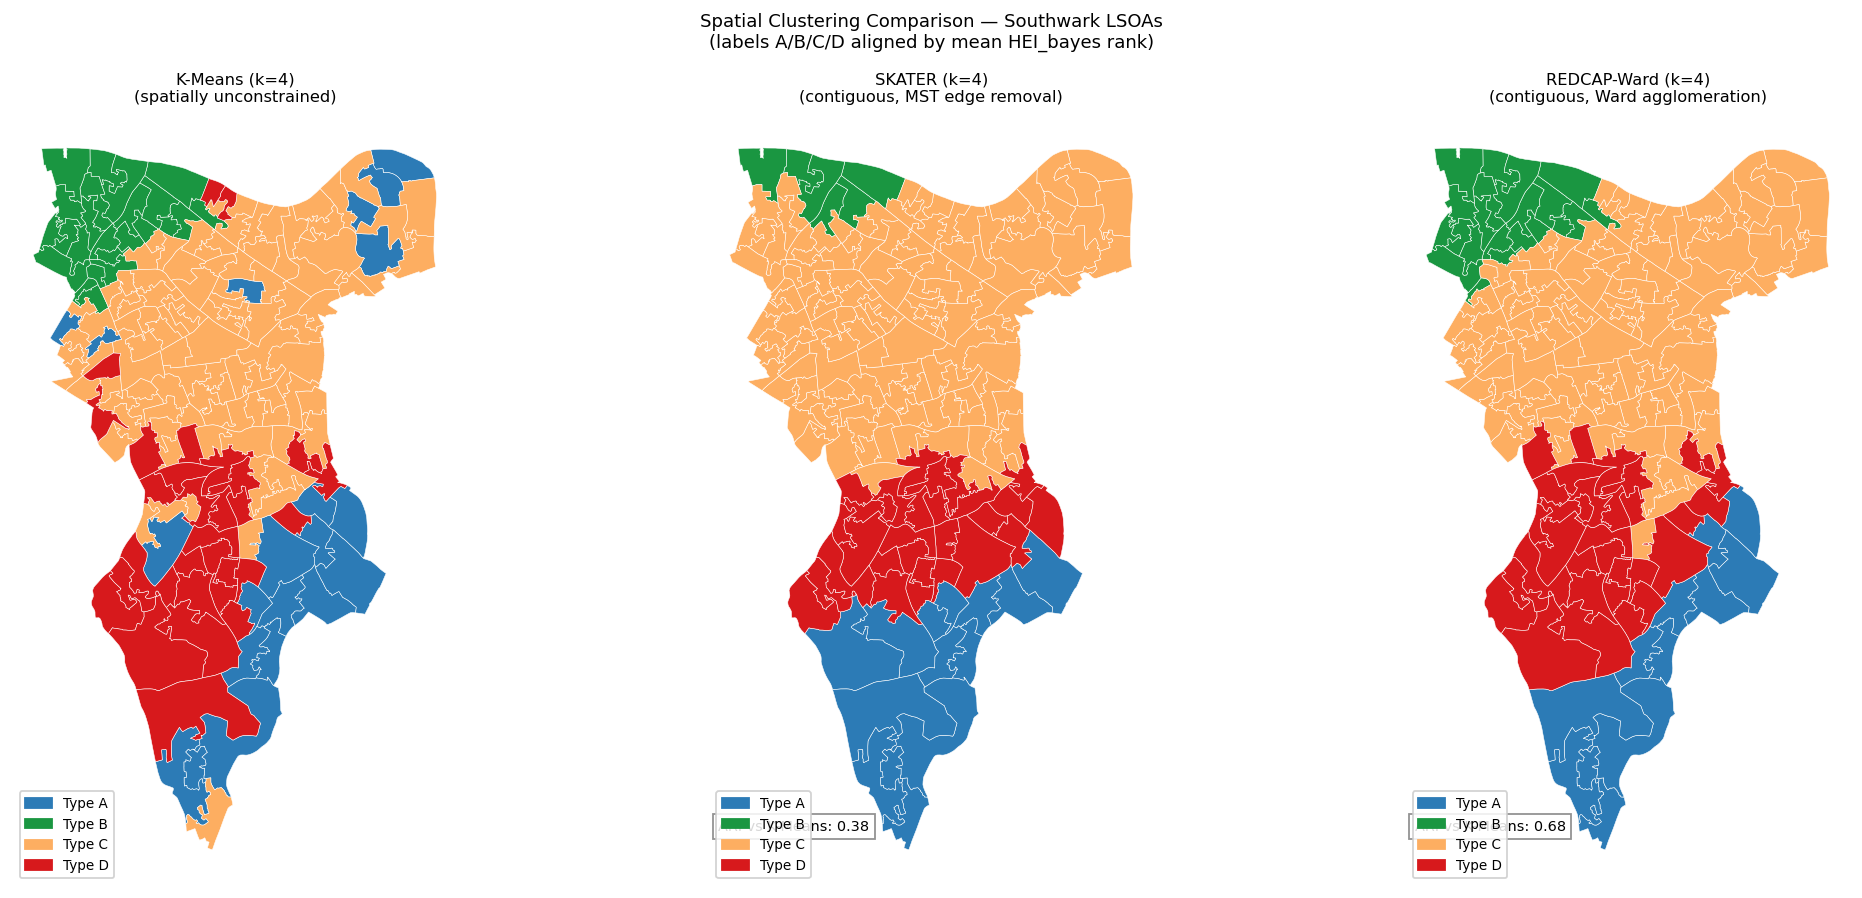

In [75]:
# --- 9.2  Spatial Comparison Maps: K-Means | SKATER | REDCAP ---
import matplotlib.patches as mpatches
import matplotlib.cm as mcm

CLUSTER_COLORS_BASE = {
    'A': '#2c7bb6', 'B': '#1a9641', 'C': '#fdae61', 'D': '#d7191c',
}

def make_color_dict(labels_series):
    """Build label→color dict. Uses CLUSTER_COLORS_BASE for A-D,
    extends with tab10 for any additional labels."""
    unique = sorted(labels_series.dropna().unique())
    extra_colors = mcm.get_cmap('tab10', max(len(unique), 10)).colors
    ei = 4  # extra colour index (after A-D)
    cdict = {}
    for lbl in unique:
        if lbl in CLUSTER_COLORS_BASE:
            cdict[lbl] = CLUSTER_COLORS_BASE[lbl]
        else:
            cdict[lbl] = '#{:02x}{:02x}{:02x}'.format(
                int(extra_colors[ei % 10][0]*255),
                int(extra_colors[ei % 10][1]*255),
                int(extra_colors[ei % 10][2]*255))
            ei += 1
    return cdict

fig, axes = plt.subplots(1, 3, figsize=(17, 7))
titles = [
    f'K-Means (k={K})\n(spatially unconstrained)',
    f'SKATER (k={K})\n(contiguous, MST edge removal)',
    f'REDCAP-Ward (k={K})\n(contiguous, Ward agglomeration)',
]
label_cols = ['cluster_type', 'skater_label', 'redcap_label']

for ax, lcol, title in zip(axes, label_cols, titles):
    cdict = make_color_dict(geo_gw[lcol])
    for lbl, color in cdict.items():
        sub = geo_gw[geo_gw[lcol] == lbl]
        if len(sub):
            sub.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3)
    geo_gw[geo_gw[lcol].isna()].plot(ax=ax, color='lightgrey', edgecolor='white', lw=0.3)
    ax.set_title(title, fontsize=9); ax.axis('off')
    patches = [mpatches.Patch(color=c, label=f'Type {l}') for l, c in cdict.items()]
    ax.legend(handles=patches, fontsize=7.5, loc='lower left', framealpha=0.85)

# ARI annotations on spatially-constrained panels
for ax, ari_val in zip(axes[1:], [ari_ks, ari_kr]):
    ax.text(0.02, 0.07, f'ARI vs K-Means: {ari_val:.2f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(fc='white', ec='grey', alpha=0.85, pad=3))

fig.suptitle('Spatial Clustering Comparison — Southwark LSOAs\n'
             '(labels A/B/C/D aligned by mean HEI_bayes rank)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'spatial_clustering_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

=== Method Comparison Summary ===
Method              Silhouette  Within-SSD   Moran I       p
------------------------------------------------------------
K-Means                  0.330       396.5     0.438   0.001
SKATER                  -0.243       393.5     0.734   0.001
REDCAP-Ward              0.281       461.1     0.688   0.001

Note: Higher Silhouette = better feature-space cohesion;
      Lower Within-SSD   = tighter clusters;
      Higher Moran I     = stronger spatial coherence.

=== K-Means × SKATER cross-tabulation ===
SKATER   A  B   C   D
K-Means              
A        9  0   7   5
B        0  6  18   0
C        1  0  91   6
D        4  0   8  18

=== K-Means × REDCAP cross-tabulation ===
REDCAP    A   B   C   D
K-Means                
A        10   0   7   4
B         0  21   3   0
C         1   0  94   3
D         1   0   4  25


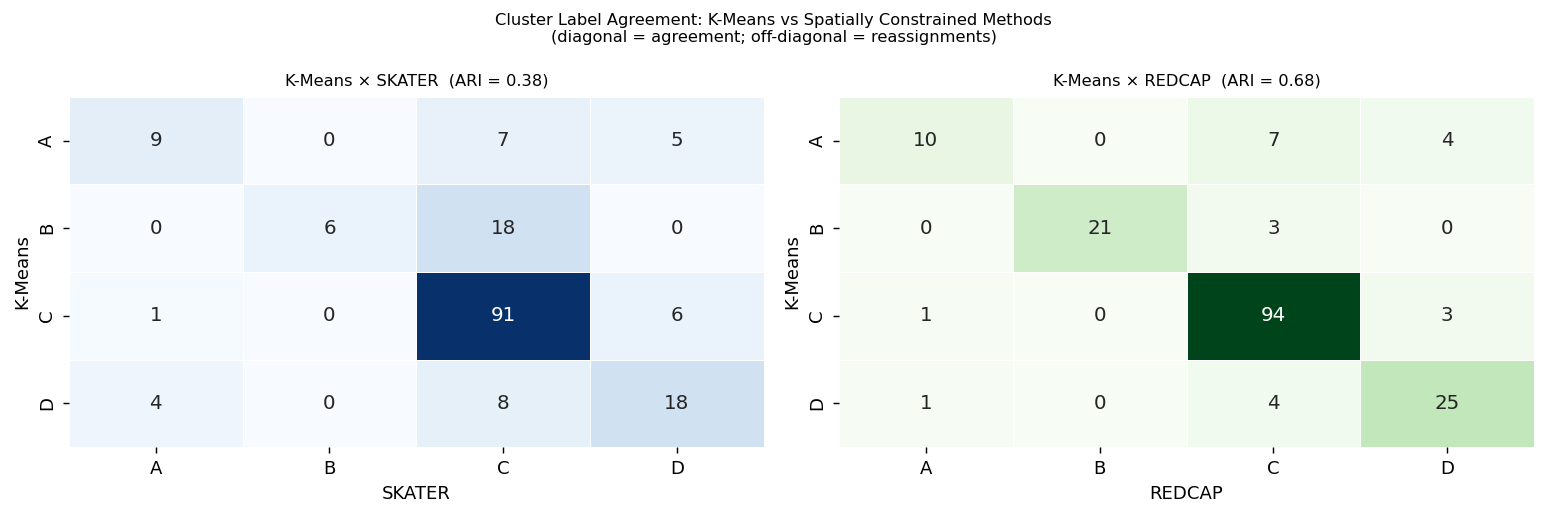


SKATER vs REDCAP ARI = 0.621


In [76]:
# --- 9.3  Cluster Comparison Metrics & Cross-tabulations ---
from sklearn.metrics import silhouette_score

# ── Silhouette scores (feature space, StandardScaler) ──────────────────────
X_sc = StandardScaler().fit_transform(feat_gw)

sil_km = silhouette_score(X_sc, kmeans_int)
sil_sk = silhouette_score(X_sc, skater_int)
sil_rc = silhouette_score(X_sc, redcap_int)

# ── Within-cluster SSD (compactness) ────────────────────────────────────────
def wssd(X, lbl):
    return sum(np.sum((X[lbl == c] - X[lbl == c].mean(0))**2)
               for c in np.unique(lbl))

wss_km = wssd(X_sc, kmeans_int)
wss_sk = wssd(X_sc, skater_int)
wss_rc = wssd(X_sc, redcap_int)

# ── Spatial coherence: Moran's I of cluster label (integer) ─────────────────
from esda.moran import Moran
W_q2 = Queen.from_dataframe(geo_gw.reset_index(drop=True), silence_warnings=True)
W_q2.transform = 'r'

mi_km = Moran(kmeans_int.astype(float), W_q2, permutations=999)
mi_sk = Moran(skater_int.astype(float), W_q2, permutations=999)
mi_rc = Moran(redcap_int.astype(float), W_q2, permutations=999)

print('=== Method Comparison Summary ===')
header = f"{'Method':<18} {'Silhouette':>11} {'Within-SSD':>11} {'Moran I':>9} {'p':>7}"
print(header)
print('-' * len(header))
for name, sil, wss, mi in [
    ('K-Means',       sil_km, wss_km, mi_km),
    ('SKATER',        sil_sk, wss_sk, mi_sk),
    ('REDCAP-Ward',   sil_rc, wss_rc, mi_rc),
]:
    print(f'{name:<18} {sil:>11.3f} {wss:>11.1f} {mi.I:>9.3f} {mi.p_sim:>7.3f}')

print('\nNote: Higher Silhouette = better feature-space cohesion;')
print('      Lower Within-SSD   = tighter clusters;')
print('      Higher Moran I     = stronger spatial coherence.')

# ── Cross-tabulations ────────────────────────────────────────────────────────
print('\n=== K-Means × SKATER cross-tabulation ===')
ct_ks = pd.crosstab(geo_gw['cluster_type'], geo_gw['skater_label'],
                     rownames=['K-Means'], colnames=['SKATER'])
print(ct_ks)

print('\n=== K-Means × REDCAP cross-tabulation ===')
ct_kr = pd.crosstab(geo_gw['cluster_type'], geo_gw['redcap_label'],
                     rownames=['K-Means'], colnames=['REDCAP'])
print(ct_kr)

# ── Heatmap side-by-side ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(ct_ks, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar=False, ax=axes[0], annot_kws={'size': 11})
axes[0].set_title(f'K-Means × SKATER  (ARI = {ari_ks:.2f})', fontsize=9)

sns.heatmap(ct_kr, annot=True, fmt='d', cmap='Greens', linewidths=0.5,
            cbar=False, ax=axes[1], annot_kws={'size': 11})
axes[1].set_title(f'K-Means × REDCAP  (ARI = {ari_kr:.2f})', fontsize=9)

fig.suptitle('Cluster Label Agreement: K-Means vs Spatially Constrained Methods\n'
             '(diagonal = agreement; off-diagonal = reassignments)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'spatial_clustering_crosstabs.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSKATER vs REDCAP ARI = {ari_sr:.3f}')

---
## 10. LISA × Cluster Overlay × Cluster Overlay

In [77]:
if 'lisa_label' in geo.columns:
    ct = pd.crosstab(geo['cluster_type'], geo['lisa_label'],
                     rownames=['Cluster Type'], colnames=['LISA'])
    print('=== Cluster Type × LISA Cross-tabulation ===')
    print(ct)

    # What % of each cluster type falls in HH (deprivation hotspot)?
    if 'HH' in ct.columns:
        pct_hh = (ct['HH'] / ct.sum(axis=1) * 100).round(1)
        print('\n% of each cluster in HH (deprivation hotspot):')
        print(pct_hh)
else:
    print('LISA data not found — run RQ3 notebook first to generate southwark_lisa.csv')

=== Cluster Type × LISA Cross-tabulation ===
LISA          HH  HL  LH  LL  ns
Cluster Type                    
A              0   0   0   8  13
B              0   0   0  15   9
C             22   1   3   0  72
D              3   0   0   1  26

% of each cluster in HH (deprivation hotspot):
Cluster Type
A    0.000
B    0.000
C   22.400
D   10.000
dtype: float64


---
## 11. Save Results Results

In [78]:
# Save SKATER and REDCAP results
sc_cols = ['lsoa21cd','lsoa21nm','skater_label','redcap_label']
sc_out  = geo_gw[[c for c in sc_cols if c in geo_gw.columns]].copy()
sc_out.to_csv(os.path.join(DATA, 'southwark_spatial_clusters.csv'), index=False)
print('Saved → southwark_spatial_clusters.csv')

# Save GWPCA results
gw_save_cols = ['lsoa21cd', 'lsoa21nm'] + [f'gw_load_{c}' for c in FEAT_COLS] + \
               ['gw_var_exp', 'gw_score', 'gw_dominant']
gw_out = geo_gw[[c for c in gw_save_cols if c in geo_gw.columns]].copy()
gw_out.to_csv(os.path.join(DATA, 'southwark_gwpca.csv'), index=False)
print('Saved → southwark_gwpca.csv')

# Save cluster assignments
out = df[['lsoa21cd','lsoa21nm','cluster_type','kmeans_label',
          'HEI_bayes'] + FEAT_COLS].copy()
out.to_csv(os.path.join(DATA, 'southwark_clusters.csv'), index=False)
print('Saved → southwark_clusters.csv')

# Save profile table
profile_table.to_csv(os.path.join(DATA, 'cluster_profile_table.csv'))
print('Saved → cluster_profile_table.csv')

print(f'\nFinal cluster distribution:')
print(out['cluster_type'].value_counts().sort_index())

Saved → southwark_spatial_clusters.csv
Saved → southwark_gwpca.csv
Saved → southwark_clusters.csv
Saved → cluster_profile_table.csv

Final cluster distribution:
cluster_type
A    21
B    24
C    98
D    30
Name: count, dtype: int64
